In [10]:
# --------------------------------------------------
# IMPORT REQUIRED LIBRARIES
# --------------------------------------------------

# Import pandas for working with data
import pandas as pd

# Import numpy for calculations
import numpy as np

# Import matplotlib for charts and graphs
import matplotlib.pyplot as plt

# Import seaborn for data visualization
import seaborn as sns

In [11]:
# --------------------------------------------------
# LOAD THE DATASET
# --------------------------------------------------

# Read the avocado dataset CSV file
avocado_info = pd.read_csv(
    r'D:\MiniForge\Ex_Files_Intro_to_Data_Science\Ex_Files_Intro_to_Data_Science\Exercise Files\avocado_info.csv'
)

# Display the first 5 rows
avocado_info.head()

,Growth Duration,Fertilizer
0,98,True
1,108,False
2,129,False
3,116,False
4,111,False


In [13]:
# --------------------------------------------------
# DISPLAY COLUMN NAMES
# --------------------------------------------------

# Show all column names
print(avocado_info.columns.tolist())

['Growth Duration', 'Fertilizer']


In [14]:
# --------------------------------------------------
# CALCULATE THE AVERAGE GROWTH DURATION
# FOR TREES THAT RECEIVED FERTILIZER
# --------------------------------------------------

# Create a subset containing fertilized trees
fertilized = avocado_info.loc[
    avocado_info['Fertilizer'] == True,
    :
]

# Calculate the average growth duration
fertilized['Growth Duration'].mean()

np.float64(113.81917211328977)

In [16]:
# --------------------------------------------------
# CREATE SUBSETS OF THE DATA
# --------------------------------------------------

# Create subset for trees WITH fertilizer
fertilized = avocado_info.loc[
    avocado_info['Fertilizer'] == True,
    :
]

# Create subset for trees WITHOUT fertilizer
not_fertilized = avocado_info.loc[
    avocado_info['Fertilizer'] == False,
    :
]

In [17]:
# --------------------------------------------------
# CREATE A TEST STATISTIC
# --------------------------------------------------

# Calculate:
# Average growth duration with fertilizer
# minus
# Average growth duration without fertilizer

observed_test_stat = (

    fertilized['Growth Duration'].mean()

    -

    not_fertilized['Growth Duration'].mean()

)

# Display the test statistic
observed_test_stat

np.float64(-9.266142572024918)

In [18]:
# --------------------------------------------------
# SORT THE DATA BY GROWTH DURATION
# --------------------------------------------------

# Sort the avocado dataset from shortest to longest growth duration
sorted_growth = avocado_info.sort_values(
    'Growth Duration',
    ascending=True
)

# Display the sorted dataset
sorted_growth

,Growth Duration,Fertilizer
323,55,False
865,58,True
35,62,False
66,63,False
1010,65,False
...,...,...
630,173,False
509,174,False
457,174,False
692,174,False


In [19]:
# --------------------------------------------------
# DISPLAY THE TOP 10 FASTEST GROWING TREES
# --------------------------------------------------

# Display the first 10 rows
sorted_growth.iloc[0:10]

,Growth Duration,Fertilizer
323,55,False
865,58,True
35,62,False
66,63,False
1010,65,False
1009,65,True
1117,68,True
405,69,True
183,71,True
272,71,False


In [20]:
# --------------------------------------------------
# COUNT HOW MANY TREES USED FERTILIZER
# --------------------------------------------------

# Count fertilizer categories
avocado_info['Fertilizer'].value_counts()

Fertilizer
False    715
True     459
Name: count, dtype: int64

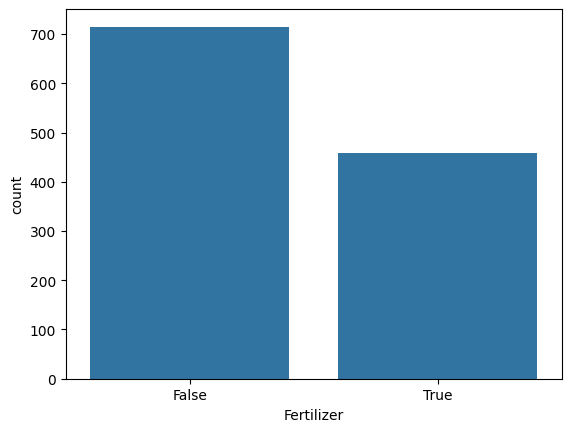

In [22]:
# --------------------------------------------------
# CREATE A BAR CHART OF FERTILIZER COUNTS
# --------------------------------------------------

# Create a count plot for fertilizer usage
sns.countplot(
    x='Fertilizer',
    data=avocado_info
)

# Display the chart
plt.show()

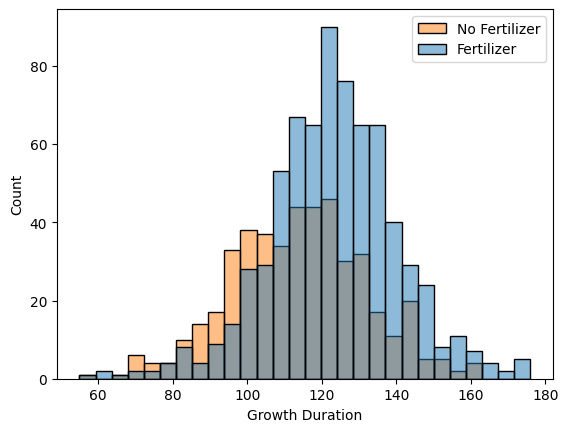

In [23]:
# --------------------------------------------------
# CREATE OVERLAID HISTOGRAMS
# TO COMPARE GROWTH DURATION
# --------------------------------------------------

# Create histograms grouped by fertilizer use
sns.histplot(
    data=avocado_info,
    x='Growth Duration',
    hue='Fertilizer'
)

# Add legend labels
plt.legend(labels=['No Fertilizer', 'Fertilizer'])

# Display the histogram
plt.show()

In [25]:
# --------------------------------------------------
# CREATE A PERMUTATION FUNCTION
# --------------------------------------------------

# Function to randomly permute data
def perm(data):

    return data.sample(
        frac=1
    ).reset_index(drop=True)

In [26]:
# --------------------------------------------------
# CREATE AN EMPTY ARRAY
# TO STORE SIMULATED TEST STATISTICS
# --------------------------------------------------

sim_test_stat = np.array([])

In [27]:
# --------------------------------------------------
# SET NUMBER OF REPETITIONS
# --------------------------------------------------

reps = 10000

In [28]:
# --------------------------------------------------
# RUN THE PERMUTATION TEST
# --------------------------------------------------

for i in range(reps):

    # Randomly permute growth duration values
    perm_info = perm(
        avocado_info["Growth Duration"]
    )

    # Create a new DataFrame
    df = pd.DataFrame({
        "Permuted Duration": perm_info,
        "Fertilizer": avocado_info["Fertilizer"]
    })

    # Subset fertilized trees
    fertilized = df.loc[
        df["Fertilizer"] == True,
        "Permuted Duration"
    ]

    # Subset non-fertilized trees
    not_fertilized = df.loc[
        df["Fertilizer"] == False,
        "Permuted Duration"
    ]

    # Calculate simulated statistic
    stat = (
        np.mean(fertilized)
        -
        np.mean(not_fertilized)
    )

    # Append statistic to array
    sim_test_stat = np.append(
        sim_test_stat,
        stat
    )

In [29]:
# --------------------------------------------------
# DISPLAY SIMULATED TEST STATISTICS
# --------------------------------------------------

sim_test_stat

array([ 0.63568719, -1.68952572,  1.2795923 , ...,  0.48186541,
       -1.75749349,  1.05780276], shape=(10000,))

In [30]:
# --------------------------------------------------
# CALCULATE THE P-VALUE
# --------------------------------------------------

p_value = np.count_nonzero(
    sim_test_stat <= observed_test_stat
) / reps

# Display the p-value
p_value

np.float64(0.0)

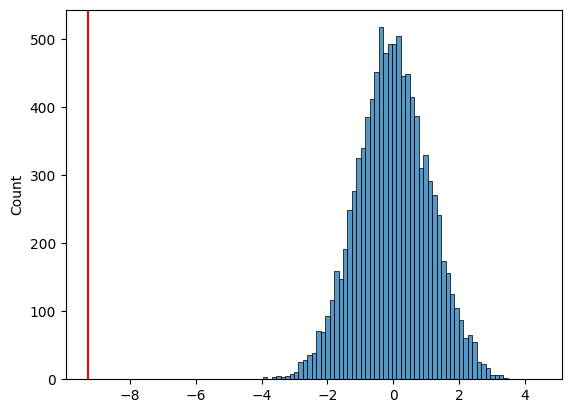

In [31]:
# --------------------------------------------------
# CREATE A HISTOGRAM OF SIMULATED
# TEST STATISTICS
# --------------------------------------------------

sns.histplot(sim_test_stat)

# Add a vertical line for observed statistic
plt.axvline(
    observed_test_stat,
    color='red'
)

# Display the histogram
plt.show()

In [35]:
# --------------------------------------------------
# CREATE MEAN VARIABLES
# --------------------------------------------------

fertilized_means = fertilized.mean()

not_fertilized_means = not_fertilized.mean()

# Display means
fertilized_means
not_fertilized_means

np.float64(119.04895104895105)

In [36]:
# --------------------------------------------------
# CALCULATE ESTIMATES
# --------------------------------------------------

estimates = (

    fertilized_means

    -

    not_fertilized_means

)

# Display estimates
estimates

np.float64(1.0578027636851175)

In [37]:
# --------------------------------------------------
# CALCULATE A 95% CONFIDENCE INTERVAL
# --------------------------------------------------

(
    np.percentile(estimates, 2.5),

    np.percentile(estimates, 97.5)

)

(np.float64(1.0578027636851175), np.float64(1.0578027636851175))

In [38]:
# --------------------------------------------------
# CREATE BOOTSTRAP ESTIMATES
# --------------------------------------------------

estimates = np.array([])

reps = 10000

for i in range(reps):

    # Bootstrap sample for fertilized trees
    fert_sample = fertilized.sample(
        frac=1,
        replace=True
    )

    # Bootstrap sample for non-fertilized trees
    not_fert_sample = not_fertilized.sample(
        frac=1,
        replace=True
    )

    # Difference in means
    estimate = (
        fert_sample.mean()
        -
        not_fert_sample.mean()
    )

    # Store estimate
    estimates = np.append(estimates, estimate)

# Display first few estimates
estimates[:10]

array([-0.35507107,  2.45963709,  2.53869312,  2.10008379, -1.07361092,
        2.79496625, -0.69955056,  1.4050307 ,  0.19047793, -0.1144446 ])

In [39]:
# --------------------------------------------------
# CALCULATE A 95% CONFIDENCE INTERVAL
# --------------------------------------------------

(
    np.percentile(estimates, 2.5),

    np.percentile(estimates, 97.5)

)

(np.float64(-1.1081550040373471), np.float64(3.236902813961636))

In [40]:
# Create growth duration subsets
fertilized = avocado_info.loc[
    avocado_info['Fertilizer'] == True,
    'Growth Duration'
]

not_fertilized = avocado_info.loc[
    avocado_info['Fertilizer'] == False,
    'Growth Duration'
]

In [41]:
# Function to resample with replacement
def resample(orig_sample):
    return np.random.choice(
        orig_sample,
        size=len(orig_sample)
    )

In [42]:
# Bootstrap function to collect many sample means
def bootstrap(orig_sample, reps):
    means = np.array([])

    for i in range(reps):
        new_sample = resample(orig_sample)
        new_mean = np.mean(new_sample)
        means = np.append(means, new_mean)

    return means

In [43]:
# Bootstrap both groups
fertilized_means = bootstrap(fertilized, 10000)
not_fertilized_means = bootstrap(not_fertilized, 10000)

# Difference in bootstrapped means
estimates = fertilized_means - not_fertilized_means

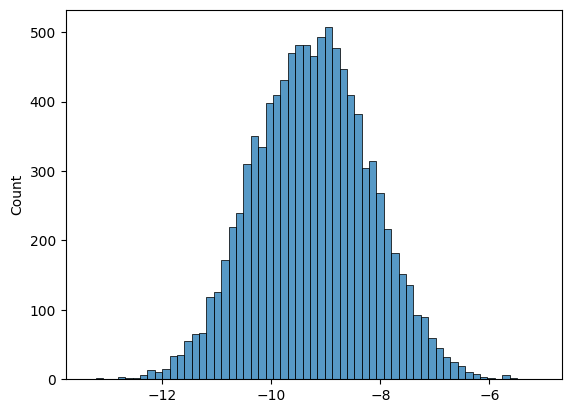

In [44]:
# Histogram of estimates
sns.histplot(estimates)
plt.show()

In [45]:
# 95% confidence interval
(
    np.percentile(estimates, 2.5),
    np.percentile(estimates, 97.5)
)

(np.float64(-11.30497204320734), np.float64(-7.179252403370048))